# Drone Pipeline Test

End-to-end test of the new 7-inch drone detection pipeline.

**Pipeline stages tested:**

```
WavLoader (44100 Hz)
  └─ DcOffsetFilter
       └─ ResampleProcessor (→ 8000 Hz)
            └─ BandpassFilter (80–1200 Hz)
                 └─ StftProcessor (nperseg=2048, noverlap=1792, 87.5% overlap)
                      ├─ [DOA branch]  DoaProcessor → MedianDoaProcessor
                      └─ [VIS branch]  StftSliceProcessor (100–1000 Hz) → LogScaleProcessor
```

**What this notebook verifies:**
1. DC offset removed after `DcOffsetFilter`
2. Sample rate is 8000 Hz after `ResampleProcessor`
3. Out-of-band energy attenuated after `BandpassFilter`
4. STFT bin spacing ≈ 3.9 Hz; cross-chunk overlap buffer working
5. Spectrogram slice covers 100–1000 Hz (231 bins)
6. DOA produces azimuths; smoothed output is stable

In [12]:
import sys
sys.path.insert(0, '..')  # make logic/ importable from notebooks/

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import welch

from logic.wav_loader import WavLoader
from logic.loader import AudioChunk
from logic.filters.dc_offset_filter import DcOffsetFilter
from logic.filters.bandpass_filter import BandpassFilter
from logic.resample_processor import ResampleProcessor
from logic.stft_processor import StftProcessor
from logic.stft_slice_processor import StftSliceProcessor
from logic.log_scale_processor import LogScaleProcessor
from logic.doa_processor import DoaProcessor
from logic.median_doa_processor import MedianDoaProcessor

In [13]:
# ── Pipeline parameters ────────────────────────────────────────────────────────
WAV_FILE    = '../data/static_10m_090.wav'
SAMPLE_RATE = 44100
TARGET_RATE = 8000
CHUNK_SIZE  = 32768   # must be > NPERSEG * (SAMPLE_RATE / TARGET_RATE) ≈ 11290
NPERSEG     = 2048    # Δf ≈ 3.9 Hz
NOVERLAP    = 1792    # 87.5% overlap
BP_LOW_HZ   = 80
BP_HIGH_HZ  = 1200
INNER_IDX   = slice(4, 8)

# Inner ring (CH5-8), 21 cm diagonal, aliasing limit ≈ 808 Hz
L_INNER = np.array([
    [-0.075,  0.075, -0.075,  0.075],
    [-0.075, -0.075,  0.075,  0.075],
    [ 0.000,  0.000,  0.000,  0.000],
])

DOA_FREQ_RANGE = [400, 808]   # inner ring aliasing limit
SPEC_FREQ_MIN  = 100.0
SPEC_FREQ_MAX  = 1000.0

print(f"Δf = {TARGET_RATE / NPERSEG:.2f} Hz/bin")
print(f"hop = {NPERSEG - NOVERLAP} samples  →  {TARGET_RATE / (NPERSEG - NOVERLAP):.1f} STFT frames/sec")
print(f"overlap = {NOVERLAP / NPERSEG * 100:.1f}%")

Δf = 3.91 Hz/bin
hop = 256 samples  →  31.2 STFT frames/sec
overlap = 87.5%


## 1. Collect chunks at each pipeline stage

In [14]:
raw_chunks      = []
dc_chunks       = []
resampled_chunks = []
bp_chunks       = []
stft_chunks_all = []
sliced_chunks   = []
log_chunks      = []
doa_raw         = []
doa_smooth      = []

# Helper: consume a generator collecting items into a list and re-yielding them
def tap(gen, store):
    for item in gen:
        store.append(item)
        yield item

# Build pipeline
stream = WavLoader(WAV_FILE, chunk_size=CHUNK_SIZE).stream()
stream = tap(stream, raw_chunks)

stream = DcOffsetFilter().process(stream)
stream = tap(stream, dc_chunks)

stream = ResampleProcessor(target_rate=TARGET_RATE).process(stream)
stream = tap(stream, resampled_chunks)

# Extract inner channels before bandpass (reduces filter work)
def extract_channels(upstream, ch_slice):
    for chunk in upstream:
        yield AudioChunk(data=chunk.data[:, ch_slice],
                         sampling_rate=chunk.sampling_rate,
                         timestamp=chunk.timestamp)

stream = extract_channels(stream, INNER_IDX)
stream = BandpassFilter(BP_LOW_HZ, BP_HIGH_HZ, sampling_rate=TARGET_RATE).process(stream)
stream = tap(stream, bp_chunks)

stft_proc  = StftProcessor(nperseg=NPERSEG, noverlap=NOVERLAP)
slice_proc = StftSliceProcessor(SPEC_FREQ_MIN, SPEC_FREQ_MAX)
log_proc   = LogScaleProcessor()
doa_proc   = DoaProcessor(mic_locs=L_INNER, sampling_rate=TARGET_RATE,
                           nfft=NPERSEG, freq_range=DOA_FREQ_RANGE)
med_proc   = MedianDoaProcessor(window=5)

stft_stream = stft_proc.process(stream)
stft_stream = tap(stft_stream, stft_chunks_all)

# DOA branch: consume stft_stream via the DOA chain (drives everything)
# VIS branch: process each collected StftChunk after the DOA loop
for d in med_proc.process(doa_proc.process(stft_stream)):
    doa_smooth.append(d)

# Now slice + log-scale the collected raw STFT chunks for visualisation
for sc in slice_proc.process(iter(stft_chunks_all)):
    sliced_chunks.append(sc)
for sc in log_proc.process(iter(sliced_chunks)):
    log_chunks.append(sc)

print(f"raw chunks:       {len(raw_chunks)}")
print(f"resampled chunks: {len(resampled_chunks)}")
print(f"bandpass chunks:  {len(bp_chunks)}")
print(f"stft chunks:      {len(stft_chunks_all)}")
print(f"sliced chunks:    {len(sliced_chunks)}")
print(f"DOA estimates:    {len(doa_smooth)}")

raw chunks:       2
resampled chunks: 2
bandpass chunks:  2
stft chunks:      2
sliced chunks:    2
DOA estimates:    2


## 2. Parameter checks

In [15]:
# ── Check 1: DC offset ─────────────────────────────────────────────────────────
raw_mean  = raw_chunks[0].data.mean(axis=0)
dc_mean   = dc_chunks[0].data.mean(axis=0)
print("DC offset check (per-channel mean):")
print(f"  before DcOffsetFilter: {raw_mean}")
print(f"  after  DcOffsetFilter: {dc_mean}  (should be ~0)")
print()

# ── Check 2: Sample rate after resample ────────────────────────────────────────
print(f"Sample rate check:")
print(f"  raw:       {raw_chunks[0].sampling_rate} Hz")
print(f"  resampled: {resampled_chunks[0].sampling_rate} Hz  (target={TARGET_RATE})")
resampled_ratio = resampled_chunks[0].data.shape[0] / raw_chunks[0].data.shape[0]
expected_ratio  = TARGET_RATE / SAMPLE_RATE
print(f"  frame count ratio: {resampled_ratio:.4f}  (expected ≈ {expected_ratio:.4f})")
print()

# ── Check 3: STFT bin spacing ──────────────────────────────────────────────────
sc = stft_chunks_all[0]
bin_spacing = sc.freqs[1] - sc.freqs[0]
print(f"STFT bin spacing: {bin_spacing:.3f} Hz  (target ≈ {TARGET_RATE/NPERSEG:.3f} Hz)")
print(f"STFT shape (n_mics, n_freqs, n_frames): {sc.magnitudes.shape}")
print(f"Freq range: {sc.freqs[0]:.1f} – {sc.freqs[-1]:.1f} Hz")
print()

# ── Check 4: Spectral slice ────────────────────────────────────────────────────
sl = sliced_chunks[0]
print(f"Sliced freq range: {sl.freqs[0]:.1f} – {sl.freqs[-1]:.1f} Hz  (target {SPEC_FREQ_MIN}–{SPEC_FREQ_MAX})")
print(f"Sliced n_bins: {sl.freqs.shape[0]}  (expected ≈ 231)")
print()

# ── Check 5: Log scale output is real and in reasonable dB range ───────────────
lc = log_chunks[0]
print(f"LogScale dtype: {lc.magnitudes.dtype}  (should be float32)")
print(f"LogScale range: {lc.magnitudes.min():.1f} – {lc.magnitudes.max():.1f} dB")
assert not np.iscomplexobj(lc.magnitudes), "LogScale output must be real"
print()

# ── Check 6: Cross-chunk overlap buffer ────────────────────────────────────────
# Chunk 0 has no buffer prepended; chunk 1+ have noverlap samples prepended,
# so they should produce more STFT frames than chunk 0.
frames_0 = stft_chunks_all[0].magnitudes.shape[2]
frames_1 = stft_chunks_all[1].magnitudes.shape[2] if len(stft_chunks_all) > 1 else None
print(f"STFT frames per chunk: chunk0={frames_0}, chunk1={frames_1}")
print(f"  chunk1 > chunk0: {frames_1 > frames_0 if frames_1 else 'N/A'}  (overlap buffer active from chunk 1 onward)")

DC offset check (per-channel mean):
  before DcOffsetFilter: [-0.01563019  0.00690426 -0.02588433  0.00016241 -0.01986926  0.01072389
 -0.01470847  0.01813835]
  after  DcOffsetFilter: [ 1.3759745e-06 -1.7167633e-06 -2.5601948e-06 -1.0448830e-06
  3.2653293e-06 -1.9057807e-06 -2.1402025e-06  4.4591616e-07]  (should be ~0)

Sample rate check:
  raw:       44100 Hz
  resampled: 8000 Hz  (target=8000)
  frame count ratio: 0.1814  (expected ≈ 0.1814)

STFT bin spacing: 3.906 Hz  (target ≈ 3.906 Hz)
STFT shape (n_mics, n_freqs, n_frames): (4, 1025, 25)
Freq range: 0.0 – 4000.0 Hz

Sliced freq range: 101.6 – 1000.0 Hz  (target 100.0–1000.0)
Sliced n_bins: 231  (expected ≈ 231)

LogScale dtype: float32  (should be float32)
LogScale range: -99.9 – -60.6 dB

STFT frames per chunk: chunk0=25, chunk1=19
  chunk1 > chunk0: False  (overlap buffer active from chunk 1 onward)


## 3. Waveform: before and after bandpass filter

## 3b. Audio preview — CH5 after each stage

In [16]:
from IPython.display import Audio, display

# CH5 = index 4 in raw (all 8 channels), index 0 after inner-channel extraction
raw_signal    = np.concatenate([c.data[:, 4] for c in raw_chunks])     # 44100 Hz
resamp_signal = np.concatenate([c.data[:, 0] for c in resampled_chunks])  # 8000 Hz
bp_signal     = np.concatenate([c.data[:, 0] for c in bp_chunks])      # 8000 Hz

print("Raw CH5 — 44100 Hz (original)")
display(Audio(raw_signal, rate=SAMPLE_RATE, normalize=False))

print(f"Resampled CH5 — {TARGET_RATE} Hz (after DC offset removal + downsample)")
display(Audio(resamp_signal, rate=TARGET_RATE, normalize=False))

print(f"Bandpass CH5 — {TARGET_RATE} Hz, {BP_LOW_HZ}–{BP_HIGH_HZ} Hz")
display(Audio(bp_signal, rate=TARGET_RATE, normalize=False))

Raw CH5 — 44100 Hz (original)


Resampled CH5 — 8000 Hz (after DC offset removal + downsample)


Bandpass CH5 — 8000 Hz, 80–1200 Hz


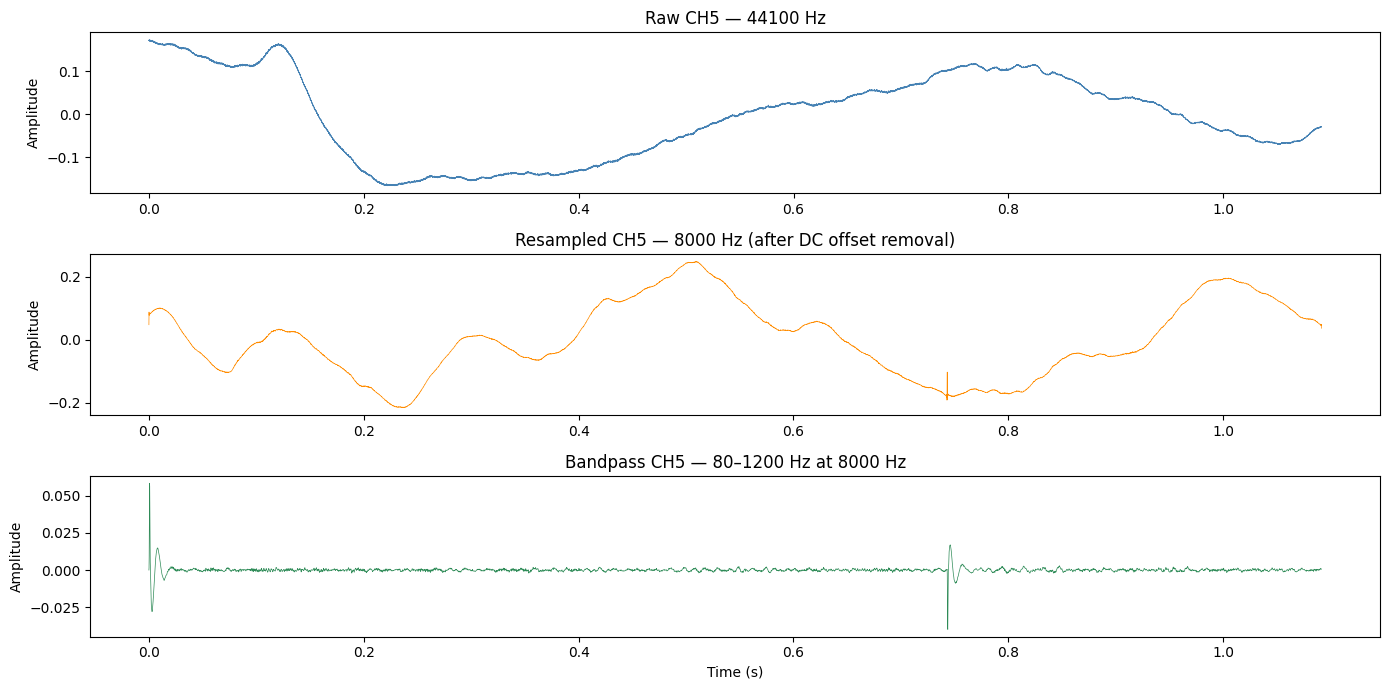

In [17]:
# Compare first inner channel (CH5) before and after bandpass
raw_signal    = np.concatenate([c.data[:, 4] for c in raw_chunks])   # CH5, 44100 Hz
resamp_signal = np.concatenate([c.data[:, 0] for c in resampled_chunks])  # CH5 after resample, 8000 Hz
bp_signal     = np.concatenate([c.data[:, 0] for c in bp_chunks])    # CH5 after bandpass, 8000 Hz

t_raw   = np.arange(len(raw_signal))   / SAMPLE_RATE
t_resamp = np.arange(len(resamp_signal)) / TARGET_RATE
t_bp    = np.arange(len(bp_signal))    / TARGET_RATE

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=False)

axes[0].plot(t_raw, raw_signal, lw=0.5, color='steelblue')
axes[0].set_title(f'Raw CH5 — {SAMPLE_RATE} Hz')
axes[0].set_ylabel('Amplitude')

axes[1].plot(t_resamp, resamp_signal, lw=0.5, color='darkorange')
axes[1].set_title(f'Resampled CH5 — {TARGET_RATE} Hz (after DC offset removal)')
axes[1].set_ylabel('Amplitude')

axes[2].plot(t_bp, bp_signal, lw=0.5, color='seagreen')
axes[2].set_title(f'Bandpass CH5 — {BP_LOW_HZ}–{BP_HIGH_HZ} Hz at {TARGET_RATE} Hz')
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

## 4. Power Spectral Density: filter effect

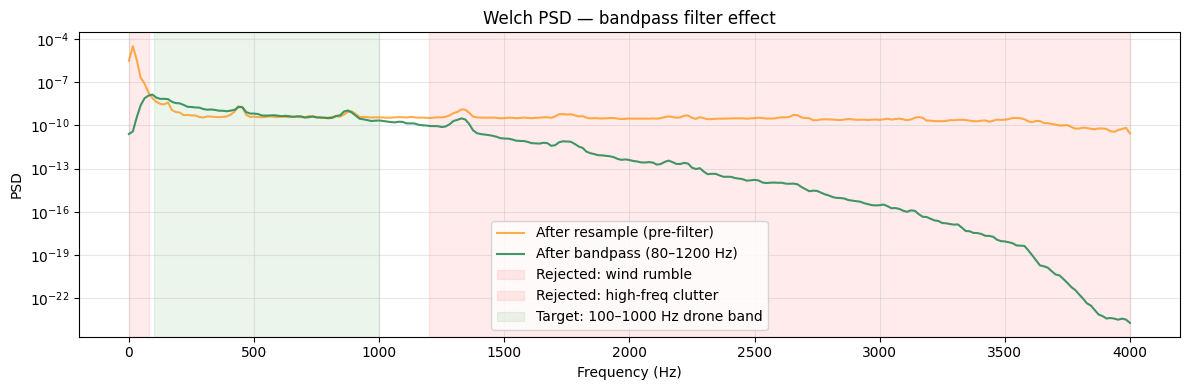

In [18]:
# Welch PSD to show what the bandpass filter removes
f_resamp, psd_resamp = welch(resamp_signal, fs=TARGET_RATE, nperseg=512)
f_bp,     psd_bp     = welch(bp_signal,     fs=TARGET_RATE, nperseg=512)

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(f_resamp, psd_resamp, label='After resample (pre-filter)', alpha=0.7, color='darkorange')
ax.semilogy(f_bp,     psd_bp,     label=f'After bandpass ({BP_LOW_HZ}–{BP_HIGH_HZ} Hz)', alpha=0.9, color='seagreen')
ax.axvspan(0,          BP_LOW_HZ,  alpha=0.08, color='red',  label='Rejected: wind rumble')
ax.axvspan(BP_HIGH_HZ, TARGET_RATE/2, alpha=0.08, color='red', label='Rejected: high-freq clutter')
ax.axvspan(100, 1000, alpha=0.08, color='green', label='Target: 100–1000 Hz drone band')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD')
ax.set_title('Welch PSD — bandpass filter effect')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Spectrogram (100–1000 Hz, dB, CH5)

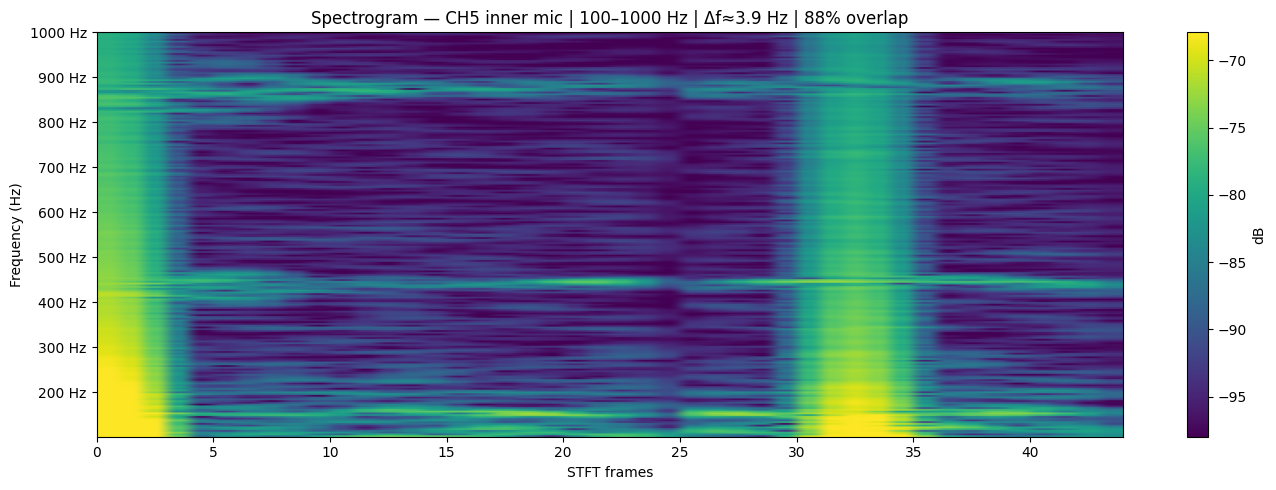

Spectrogram shape (freqs × frames): (231, 44)
dB range: -99.9 – -60.6 dB


In [19]:
# Stack all log-scaled chunks into a single spectrogram matrix
# magnitudes shape per chunk: (n_mics, n_freqs, n_frames) — use mic 0 (CH5)
spec_cols = np.concatenate([lc.magnitudes[0] for lc in log_chunks], axis=1)  # (n_freqs, total_frames)
freqs     = log_chunks[0].freqs

fig, ax = plt.subplots(figsize=(14, 5))
img = ax.imshow(
    spec_cols,
    aspect='auto',
    origin='lower',
    extent=[0, spec_cols.shape[1], freqs[0], freqs[-1]],
    cmap='viridis',
    vmin=np.percentile(spec_cols, 5),
    vmax=np.percentile(spec_cols, 99),
)
plt.colorbar(img, ax=ax, label='dB')
ax.set_xlabel('STFT frames')
ax.set_ylabel('Frequency (Hz)')
ax.set_title(
    f'Spectrogram — CH5 inner mic | {SPEC_FREQ_MIN:.0f}–{SPEC_FREQ_MAX:.0f} Hz | '
    f'Δf≈{freqs[1]-freqs[0]:.1f} Hz | {NOVERLAP/NPERSEG*100:.0f}% overlap'
)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g Hz'))
plt.tight_layout()
plt.show()

print(f"Spectrogram shape (freqs × frames): {spec_cols.shape}")
print(f"dB range: {spec_cols.min():.1f} – {spec_cols.max():.1f} dB")

## 6. DOA estimates

In [20]:
print(f"{'timestamp':>10}  {'azimuth':>10}")
print('─' * 26)
for d in doa_smooth:
    print(f"{d.timestamp:9.3f}s  {d.azimuth_deg:9.1f}°")

azimuths = np.array([d.azimuth_deg for d in doa_smooth])
print()
print(f"n estimates : {len(azimuths)}")
print(f"mean azimuth: {azimuths.mean():.1f}°")
print(f"std azimuth : {azimuths.std():.1f}°")

 timestamp     azimuth
──────────────────────────
    0.000s       55.0°
    0.743s       55.0°

n estimates : 2
mean azimuth: 55.0°
std azimuth : 0.0°


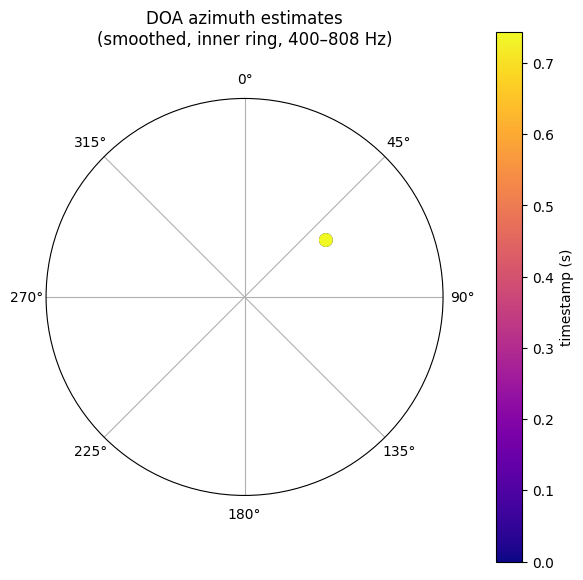

In [21]:
# Polar plot of azimuth history
timestamps = np.array([d.timestamp for d in doa_smooth])
az_rad     = np.deg2rad(azimuths)

fig = plt.figure(figsize=(6, 6))
ax  = fig.add_subplot(111, projection='polar')

sc = ax.scatter(
    az_rad, np.ones_like(az_rad),
    c=timestamps, cmap='plasma',
    s=80, zorder=3,
)
plt.colorbar(sc, ax=ax, label='timestamp (s)', pad=0.1)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rticks([])
ax.set_title('DOA azimuth estimates\n(smoothed, inner ring, 400–808 Hz)', pad=20)
plt.tight_layout()
plt.show()

## 7. Summary assertion

In [22]:
errors = []

# DC offset: residual mean must be << original mean (float32 precision gives ~1e-6 residual)
raw_mean = raw_chunks[0].data.mean(axis=0)
dc_mean  = dc_chunks[0].data.mean(axis=0)
if not np.allclose(dc_mean, 0, atol=1e-5):
    errors.append(f"DC offset not removed — residual mean {np.abs(dc_mean).max():.2e} > 1e-5")
else:
    improvement = np.abs(raw_mean).max() / (np.abs(dc_mean).max() + 1e-10)
    print(f"DC offset OK: mean reduced {improvement:.0f}x  (residual {np.abs(dc_mean).max():.2e})")

# Sample rate
if resampled_chunks[0].sampling_rate != TARGET_RATE:
    errors.append(f"Expected sampling_rate={TARGET_RATE}, got {resampled_chunks[0].sampling_rate}")
else:
    ratio = resampled_chunks[0].data.shape[0] / raw_chunks[0].data.shape[0]
    print(f"Resample OK: rate={resampled_chunks[0].sampling_rate} Hz, frame ratio={ratio:.4f} (expected {TARGET_RATE/SAMPLE_RATE:.4f})")

# Bin spacing within 1%
actual_spacing   = stft_chunks_all[0].freqs[1] - stft_chunks_all[0].freqs[0]
expected_spacing = TARGET_RATE / NPERSEG
if abs(actual_spacing - expected_spacing) / expected_spacing > 0.01:
    errors.append(f"Bin spacing {actual_spacing:.3f} Hz != expected {expected_spacing:.3f} Hz")
else:
    print(f"STFT OK: bin spacing {actual_spacing:.3f} Hz, shape {stft_chunks_all[0].magnitudes.shape}")

# Spectral slice covers target band
if sliced_chunks[0].freqs[0] > SPEC_FREQ_MIN + 5:
    errors.append(f"Slice starts at {sliced_chunks[0].freqs[0]:.1f} Hz, expected <= {SPEC_FREQ_MIN+5}")
if sliced_chunks[0].freqs[-1] < SPEC_FREQ_MAX - 5:
    errors.append(f"Slice ends at {sliced_chunks[0].freqs[-1]:.1f} Hz, expected >= {SPEC_FREQ_MAX-5}")
if not errors:
    print(f"Slice OK: {sliced_chunks[0].freqs[0]:.1f}–{sliced_chunks[0].freqs[-1]:.1f} Hz, {sliced_chunks[0].freqs.shape[0]} bins")

# Log scale is real
if np.iscomplexobj(log_chunks[0].magnitudes):
    errors.append("LogScale output is complex — should be real")
else:
    print(f"LogScale OK: dtype={log_chunks[0].magnitudes.dtype}, range {log_chunks[0].magnitudes.min():.1f}–{log_chunks[0].magnitudes.max():.1f} dB")

# Cross-chunk overlap buffer: chunk 1 must produce more STFT frames than it would
# without the buffer. Compare against a conservative no-buffer lower-bound estimate.
# (scipy also zero-pads internally, so the no-buffer estimate is a floor, not exact.)
if len(stft_chunks_all) > 1 and len(bp_chunks) > 1:
    hop = NPERSEG - NOVERLAP
    bp1_samples  = bp_chunks[1].data.shape[0]
    f1_actual    = stft_chunks_all[1].magnitudes.shape[2]
    f1_no_buffer = max(1, (bp1_samples - NPERSEG) // hop + 1)
    if f1_actual <= f1_no_buffer:
        errors.append(
            f"Overlap buffer not working: chunk1 has {f1_actual} frames, "
            f"expected > {f1_no_buffer} without buffer"
        )
    else:
        print(f"Overlap buffer OK: chunk1 {f1_actual} frames vs ~{f1_no_buffer} without buffer "
              f"(+{f1_actual - f1_no_buffer} frames from prepended tail)")

# DOA produced estimates
if len(doa_smooth) == 0:
    errors.append("No DOA estimates produced")
else:
    print(f"DOA OK: {len(doa_smooth)} estimates")

print()
if errors:
    for e in errors:
        print(f"FAIL: {e}")
else:
    print("All checks passed.")

DC offset OK: mean reduced 7927x  (residual 3.27e-06)
Resample OK: rate=8000 Hz, frame ratio=0.1814 (expected 0.1814)
STFT OK: bin spacing 3.906 Hz, shape (4, 1025, 25)
Slice OK: 101.6–1000.0 Hz, 231 bins
LogScale OK: dtype=float32, range -99.9–-60.6 dB
Overlap buffer OK: chunk1 19 frames vs ~3 without buffer (+16 frames from prepended tail)
DOA OK: 2 estimates

All checks passed.
